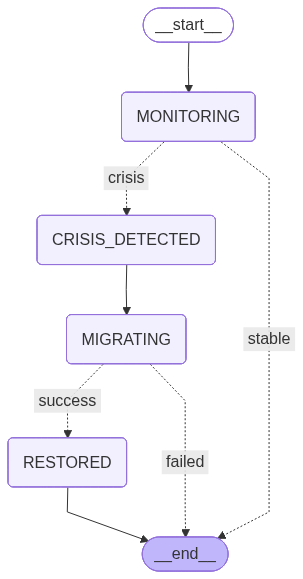

In [2]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, END
from Work_flow.Graph_State_Schema import GridState


from Work_flow.Nodes.Monitor_Node import monitor
from Work_flow.Nodes.Detect_Crisis_Node import detect_crisis
from Work_flow.Nodes.Migrate_Node import migrate
from Work_flow.Nodes.Restored_Node import restored


from Work_flow.Conditional_Edges import should_migrate, migration_result

def build_auragrid_brain():
    
    graph = StateGraph(GridState)
    
    
    graph.add_node("MONITORING", monitor)
    graph.add_node("CRISIS_DETECTED", detect_crisis)
    graph.add_node("MIGRATING", migrate)
    graph.add_node("RESTORED", restored)
    
    
    graph.set_entry_point("MONITORING")
    
    
    graph.add_conditional_edges(
        "MONITORING",
        should_migrate,
        {
            "crisis": "CRISIS_DETECTED",
            "stable": END
        }
    )
    
    
    graph.add_edge("CRISIS_DETECTED", "MIGRATING")
    
    
    graph.add_conditional_edges(
        "MIGRATING",
        migration_result,
        {
            "success": "RESTORED",
            "failed": END
        }
    )
    
    
    graph.add_edge("RESTORED", END)
    
    
    return graph.compile()


auragrid_brain = build_auragrid_brain()

display(Image(auragrid_brain.get_graph().draw_mermaid_png()))